In [100]:
import pandas as pd 
df = pd.read_csv('./corrected_dataset.csv');
df.head(2)

,gender,course,year,internet_access,class_type,weather,absence_reason,sleep_time
0,male,pharmacy,1st year,no,offline,sunny,none,Moyen
1,male,b.sc,3rd year,yes,online,rainy,none,Court


In [101]:
qualitative_cols = df.select_dtypes(include=['object', 'category']).columns
P = len(qualitative_cols)
J = sum([df[var].nunique() for var in qualitative_cols])
n_components_max = J - P
n_components_max

26

In [102]:
print(1/P)

0.125


In [103]:
  
from prince import MCA
mca = MCA(
    n_components=n_components_max,  # Tous les axes
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(df)

In [104]:
print(mca.eigenvalues_)

[0.16747935 0.15282522 0.15186583 0.1474884  0.14359796 0.1412591
 0.13842667 0.13380292 0.1330302  0.13023575 0.12917704 0.12792721
 0.12508094 0.12478104 0.12215861 0.11888924 0.11772478 0.11501408
 0.11052221 0.11006559 0.10849645 0.10720861 0.10252061 0.10084241
 0.09513291 0.09444686]


In [105]:
print(mca.eigenvalues_summary)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.167         5.15%                      5.15%
1              0.153         4.70%                      9.86%
2              0.152         4.67%                     14.53%
3              0.147         4.54%                     19.07%
4              0.144         4.42%                     23.48%
5              0.141         4.35%                     27.83%
6              0.138         4.26%                     32.09%
7              0.134         4.12%                     36.21%
8              0.133         4.09%                     40.30%
9              0.130         4.01%                     44.31%
10             0.129         3.97%                     48.28%
11             0.128         3.94%                     52.22%
12             0.125         3.85%                     56.07%
13             0.125         3.84%                     59.91%
14      

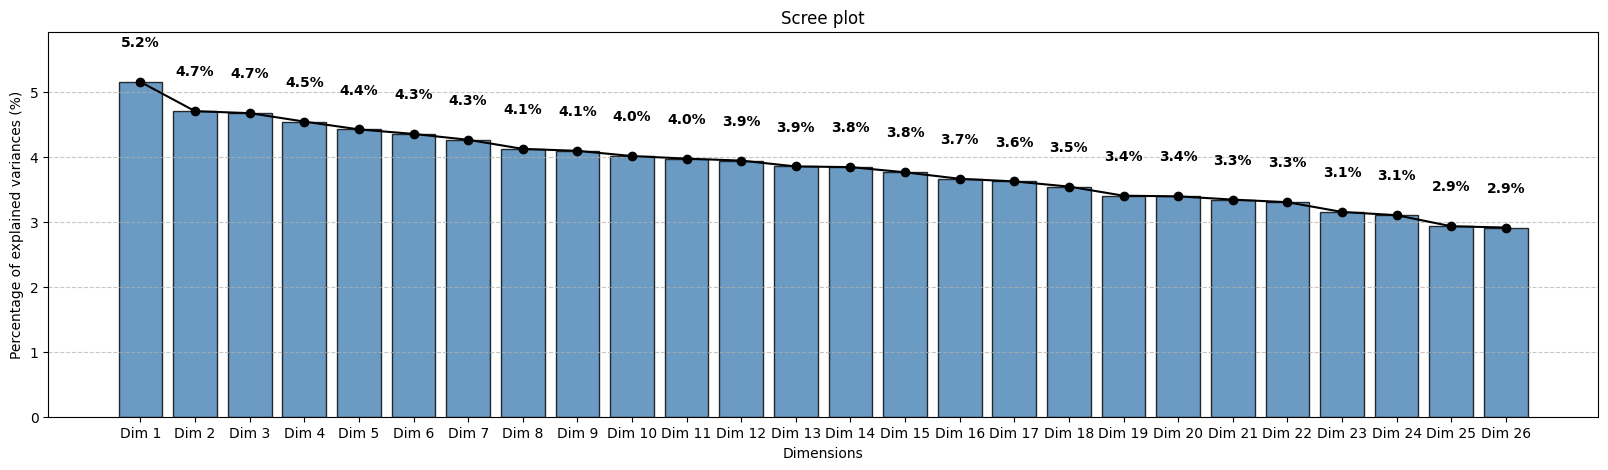

In [106]:
import matplotlib.pyplot as plt
import numpy as np


summary = mca.eigenvalues_summary

perc_var = summary['% of variance'].str.rstrip('%').astype(float).values


x = range(1, len(perc_var)+1)
dims = [f'Dim {i}' for i in x]


plt.figure(figsize=(20, 5))
bars = plt.bar(x, perc_var, color='steelblue', edgecolor='black', alpha=0.8)


plt.plot(x, perc_var, marker='o', color='black', linestyle='-', linewidth=1.5)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.xticks(x, dims)  
plt.ylabel('Percentage of explained variances (%)')
plt.xlabel('Dimensions')
plt.title('Scree plot')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(perc_var)*1.15)  
plt.show()


In [107]:
mca.row_coordinates(df).head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.156174,0.478274,-0.738838,-0.574296,0.787987,0.135207,0.188127,0.019750,0.236008,-0.054537,...,0.032504,-0.139454,-0.092679,0.440510,0.009896,-0.122370,0.110550,-0.234033,0.126260,0.407972
1,0.227993,-0.543130,0.057004,0.257021,-0.794364,0.255281,0.414223,-0.156124,-0.366353,-0.282974,...,0.098943,0.011834,-0.264228,0.480491,-0.139968,-0.105865,0.077287,-0.144519,-0.144249,-0.224188
2,-0.204676,-0.497110,0.252147,-0.090710,1.201728,-0.234963,0.122139,0.015535,-0.110865,-0.142558,...,0.280897,0.054692,-0.110885,0.173262,0.284913,0.714241,0.863646,-0.251212,0.464381,0.100081
3,0.305757,0.264335,0.188589,-0.171288,-0.427246,-0.110948,0.183482,-0.446127,0.106338,-0.116209,...,-0.024076,0.381436,0.081985,-0.004843,0.329121,0.460006,0.268185,-0.455785,-0.070165,0.475638
4,-0.330204,-0.155084,0.416813,-0.168719,0.255675,0.071726,0.541536,-0.153194,0.025914,-0.015610,...,-0.080966,-0.058735,0.389783,0.130200,0.531427,-0.162431,-0.549260,-0.067101,-0.326479,0.468321


In [108]:
mca.column_coordinates(df).head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
gender__female,-0.247883,-0.020493,0.266613,-0.076049,0.290077,-0.488354,-0.247294,0.048113,-0.006310,-0.020717,...,0.127859,-0.093298,-0.021567,-0.102814,0.316597,0.069632,-0.307205,0.112868,-0.078223,-0.298723
gender__male,0.251881,0.020823,-0.270913,0.077276,-0.294756,0.496230,0.251283,-0.048889,0.006412,0.021052,...,-0.129921,0.094803,0.021915,0.104473,-0.321703,-0.070755,0.312160,-0.114688,0.079485,0.303541
course__b.com,0.448427,0.288953,-0.251963,0.105085,0.091062,0.936436,-0.586677,-1.082752,0.486878,1.522029,...,0.193759,0.789740,0.913133,-0.628602,0.285068,0.145449,-0.087500,0.308476,0.485972,-0.391063
course__b.sc,0.910933,-0.602553,-0.093200,0.285461,-0.626041,0.259254,0.971039,0.158135,-0.309458,-0.714191,...,-0.134831,-0.169523,-0.555677,0.246994,-0.065758,0.697356,-0.241614,0.965786,-0.266814,0.016342
course__b.tech,-0.186117,0.635484,1.137261,-0.468211,-0.439990,-0.079671,0.440591,-0.906769,-0.034374,-0.782382,...,-0.495889,0.163638,0.473255,0.557959,1.013899,-0.109386,0.056818,-0.043816,0.002548,0.853320


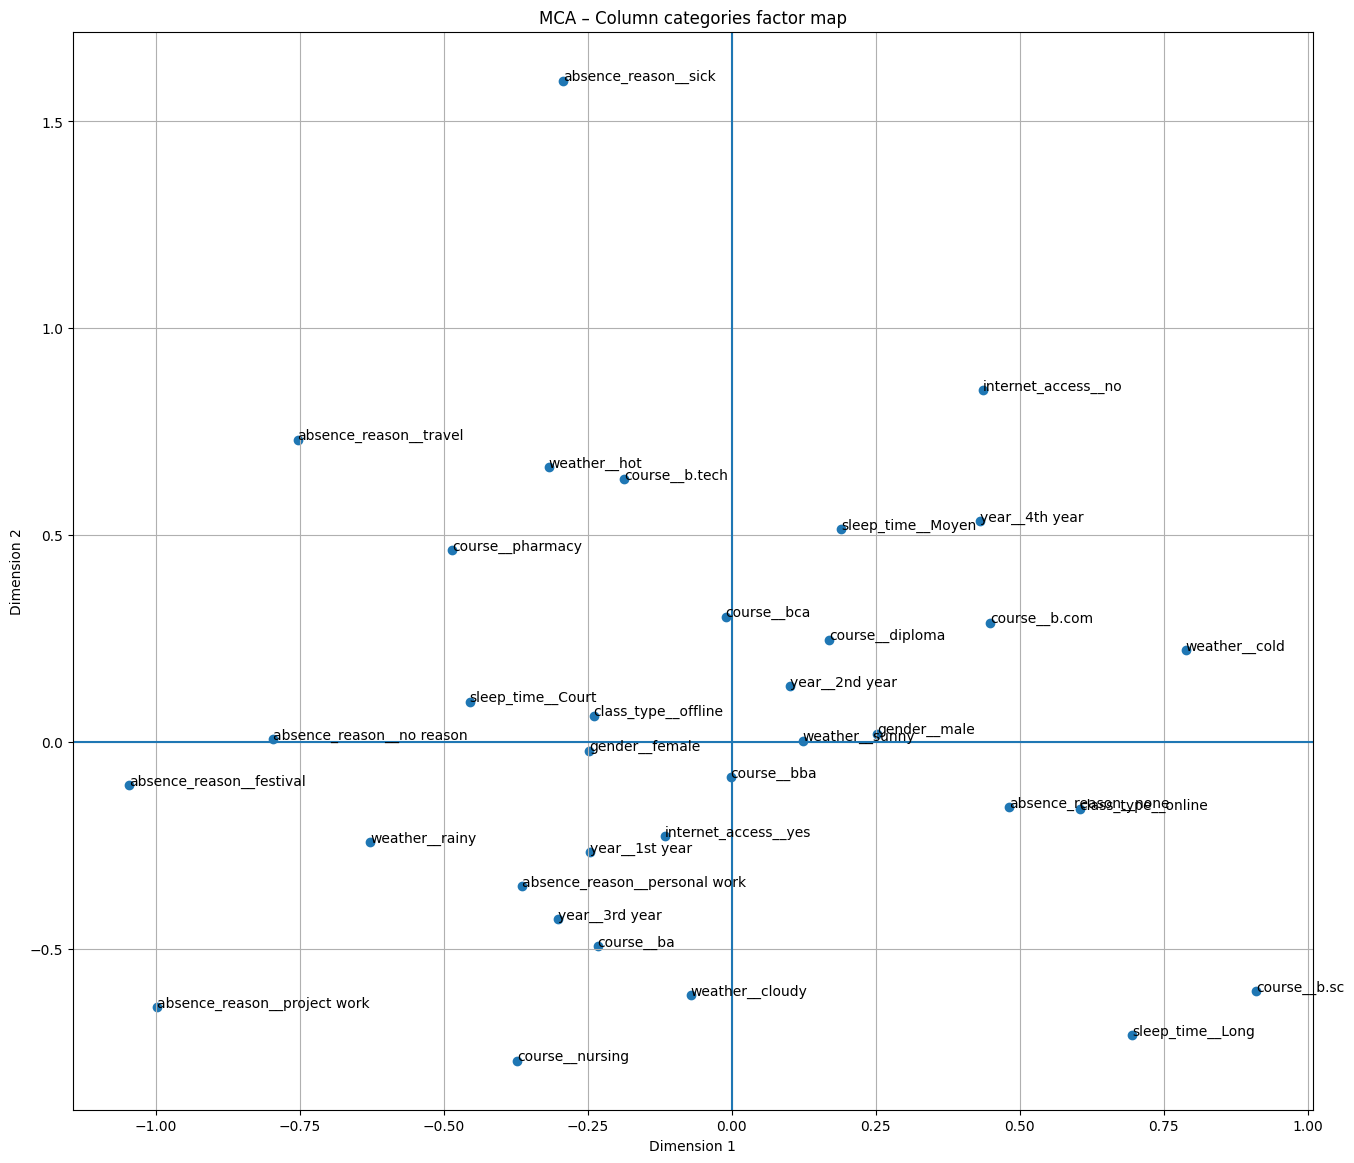

In [109]:
import matplotlib.pyplot as plt
col_coord = mca.column_coordinates(df)

plt.figure(figsize=(16, 14))

plt.scatter(
    col_coord.iloc[:, 0],
    col_coord.iloc[:, 1]
)

for i, label in enumerate(col_coord.index):
    plt.text(
        col_coord.iloc[i, 0],
        col_coord.iloc[i, 1],
        label,
        fontsize=10
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("MCA – Column categories factor map")

plt.grid(True)
plt.show()


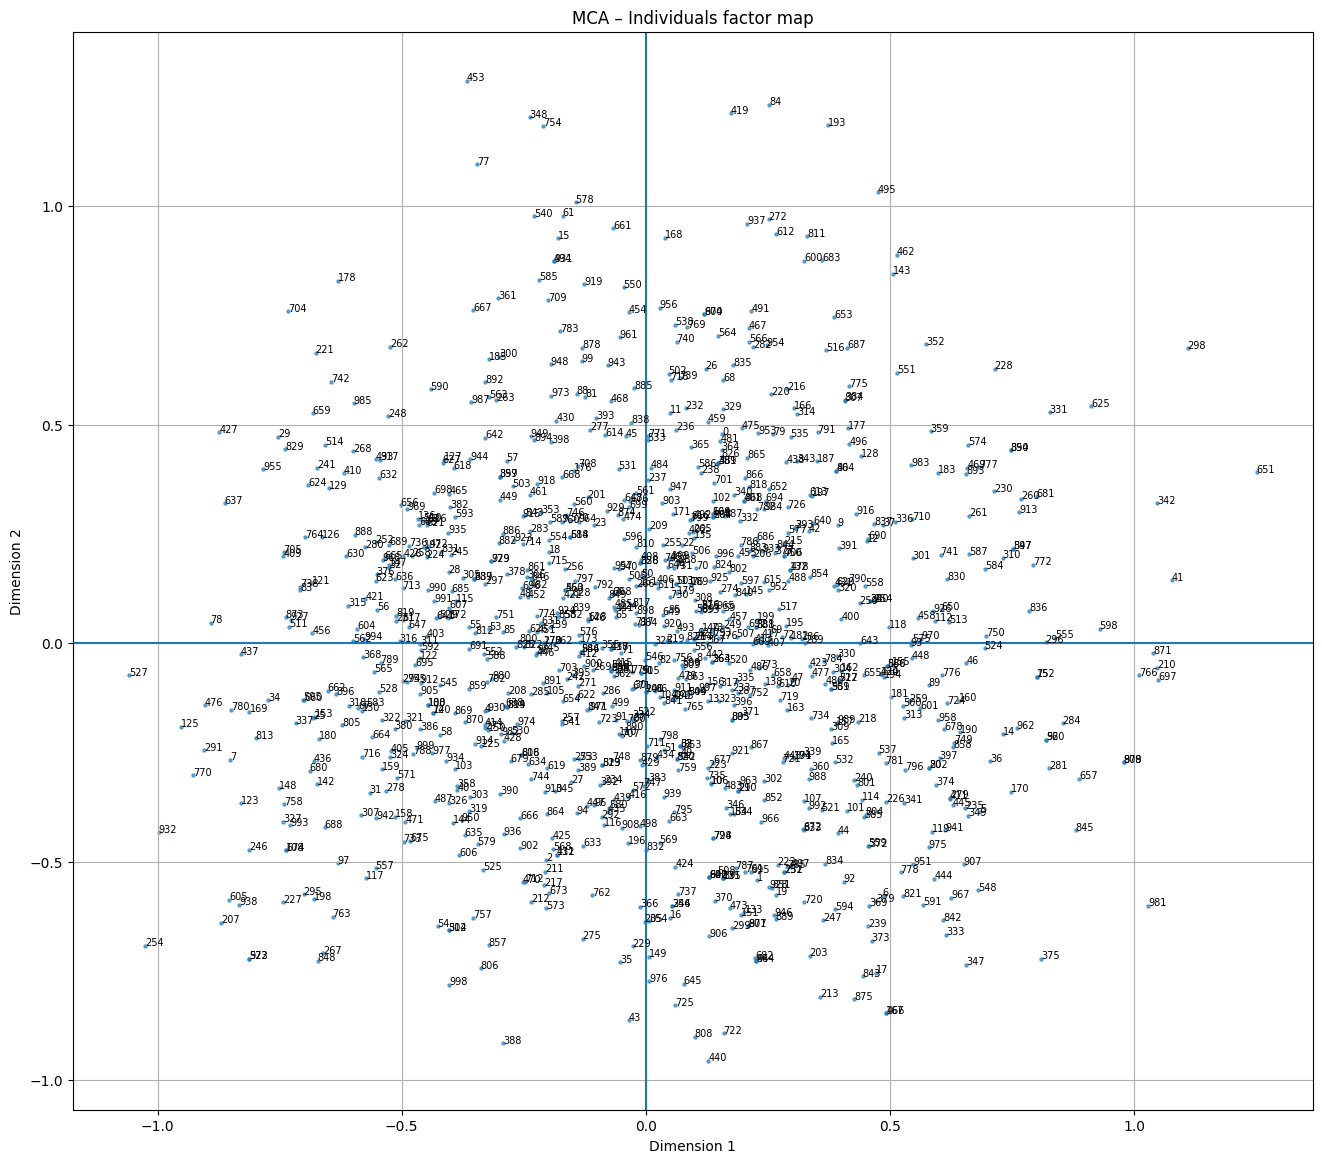

In [110]:
row_coord = mca.row_coordinates(df)

plt.figure(figsize=(16, 14))

plt.scatter(
    row_coord.iloc[:, 0],
    row_coord.iloc[:, 1],
    s=5,         
    alpha=0.6    
)

for i, label in enumerate(row_coord.index):
    plt.text(
        row_coord.iloc[i, 0],
        row_coord.iloc[i, 1],
        label,
        fontsize=7
    )

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("MCA – Individuals factor map")

plt.grid(True)
plt.show()


In [111]:
row_contrib = mca.row_contributions_ * 100
row_contrib.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.014563,0.149678,0.359450,0.223621,0.432405,0.012941,0.025567,0.000292,0.041870,0.002284,...,0.000897,0.016909,0.007772,0.176303,0.000090,0.013967,0.011921,0.054314,0.016757,0.176227
1,0.031037,0.193024,0.002140,0.044790,0.439431,0.046134,0.123951,0.018217,0.100890,0.061484,...,0.008316,0.000122,0.063170,0.209758,0.018057,0.010454,0.005826,0.020711,0.021872,0.053215
2,0.025013,0.161700,0.041865,0.005579,1.005690,0.039082,0.010777,0.000180,0.009239,0.015605,...,0.067023,0.002601,0.011125,0.027274,0.074818,0.475839,0.727546,0.062580,0.226683,0.010605
3,0.055820,0.045721,0.023419,0.019893,0.127118,0.008714,0.024320,0.148748,0.008500,0.010369,...,0.000492,0.126501,0.006082,0.000021,0.099838,0.197377,0.070155,0.206004,0.005175,0.239533
4,0.065104,0.015738,0.114399,0.019301,0.045523,0.003642,0.211853,0.017540,0.000505,0.000187,...,0.005568,0.002999,0.137466,0.015402,0.260298,0.024610,0.294269,0.004465,0.112042,0.232220


In [112]:
n = 1000
contrib_moyenne = 100 / n
for i in range(2):
    print(f"--- Modalités contributives pour l'Axe {i} (Seuil > {contrib_moyenne:.2f}%) ---")
    
    selection = row_contrib[row_contrib[i] > contrib_moyenne][i].sort_values(ascending=False)
    
    
    df_bilan = pd.DataFrame({
        'Contribution (%)': selection,
    })
    
    print(df_bilan)
    print("\n")

--- Modalités contributives pour l'Axe 0 (Seuil > 0.10%) ---
     Contribution (%)
651          0.933709
298          0.734664
41           0.693022
527          0.668457
697          0.657105
..                ...
790          0.102524
127          0.102420
177          0.101971
687          0.101592
101          0.100868

[335 rows x 1 columns]


--- Modalités contributives pour l'Axe 1 (Seuil > 0.10%) ---
     Contribution (%)
453          1.083930
84           0.993035
419          0.962031
348          0.947546
193          0.920315
..                ...
176          0.101793
307          0.101542
804          0.100914
184          0.100506
864          0.100012

[321 rows x 1 columns]




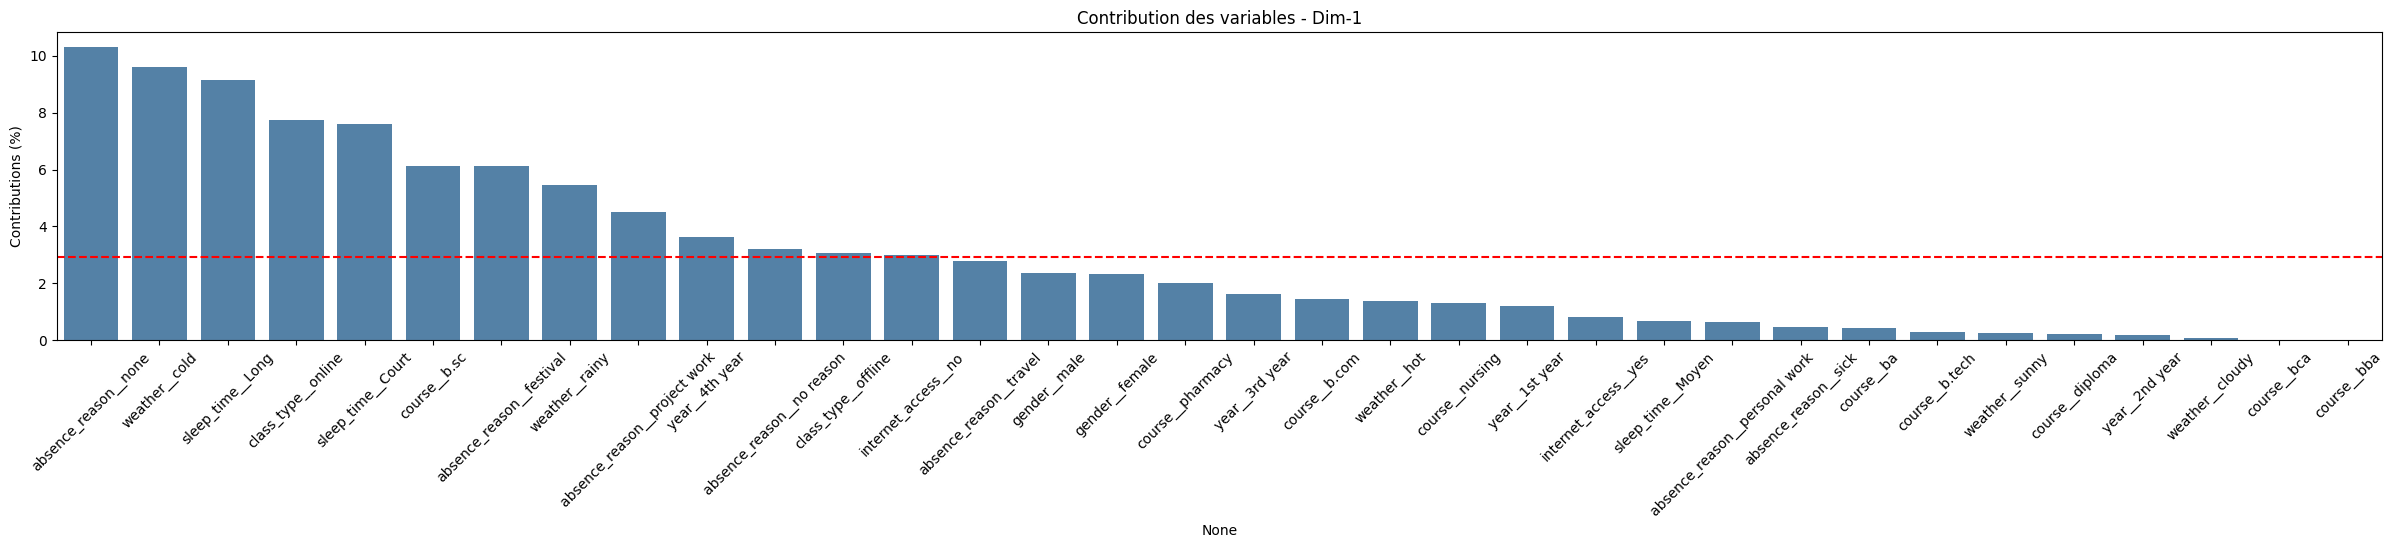

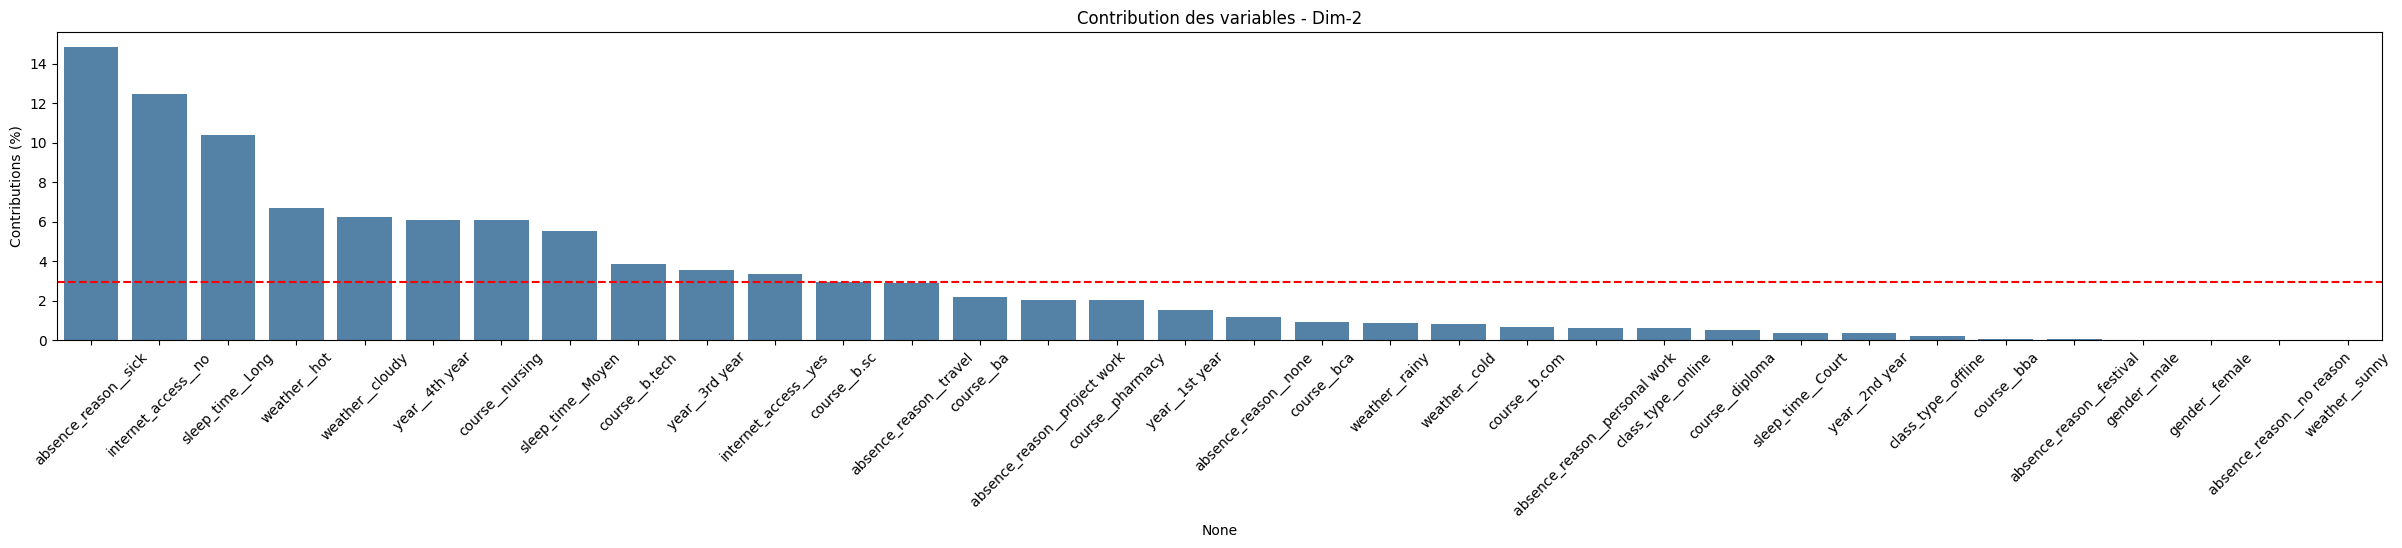

In [113]:
def plot_contrib(mca_obj, axis_index, title):
    contrib = mca_obj.column_contributions_ * 100
    n_mod = len(contrib)
    threshold = 100 / n_mod
    
    data = contrib[axis_index].sort_values(ascending=False)
    
    plt.figure(figsize=(30, 4))
    sns.barplot(x=data.index, y=data.values, color='steelblue')
    plt.axhline(y=threshold, color='red', linestyle='--') 
    plt.title(title)
    plt.ylabel("Contributions (%)")
    plt.xticks(rotation=45)
    plt.show()

# Appels pour les deux axes
plot_contrib(mca, 0, "Contribution des variables - Dim-1")
plot_contrib(mca, 1, "Contribution des variables - Dim-2")

In [114]:
qualit_indiv = mca.row_cosine_similarities(df)
qualite_plan = qualit_indiv[[0, 1]].sum(axis=1)

df_qualite = pd.DataFrame({
    'Cos2_Axe0': qualit_indiv[0],
    'Cos2_Axe1': qualit_indiv[1],
    'Qualite_Plan': qualite_plan
})

print(df_qualite.sort_values(by='Qualite_Plan', ascending=False).head(10))

     Cos2_Axe0  Cos2_Axe1  Qualite_Plan
651   0.469081   0.045763      0.514844
298   0.366224   0.135875      0.502099
981   0.365876   0.124627      0.490503
453   0.031434   0.385774      0.417208
375   0.224029   0.178774      0.402803
809   0.363321   0.028260      0.391581
978   0.363321   0.028260      0.391581
254   0.257504   0.117402      0.374907
348   0.013947   0.356801      0.370748
342   0.332042   0.031123      0.363165


In [115]:
qualit_modal = mca.column_cosine_similarities(df)

qualite_plan = qualit_modal[[0, 1]].sum(axis=1)

df_qualite = pd.DataFrame({
    'Cos2_Axe0': qualit_modal[0],
    'Cos2_Axe1': qualit_modal[1],
    'Qualite_Plan': qualite_plan
})

print(df_qualite.sort_values(by='Qualite_Plan', ascending=False).head(10))

                      Cos2_Axe0  Cos2_Axe1  Qualite_Plan
absence_reason__none   0.341947   0.036301      0.378248
sleep_time__Long       0.163917   0.169741      0.333657
internet_access__no    0.050774   0.193311      0.244084
internet_access__yes   0.050774   0.193311      0.244084
sleep_time__Court      0.201284   0.009359      0.210643
absence_reason__sick   0.006570   0.195295      0.201865
weather__cold          0.162241   0.012910      0.175151
year__4th year         0.065495   0.100182      0.165677
class_type__offline    0.144630   0.010304      0.154933
class_type__online     0.144630   0.010304      0.154933


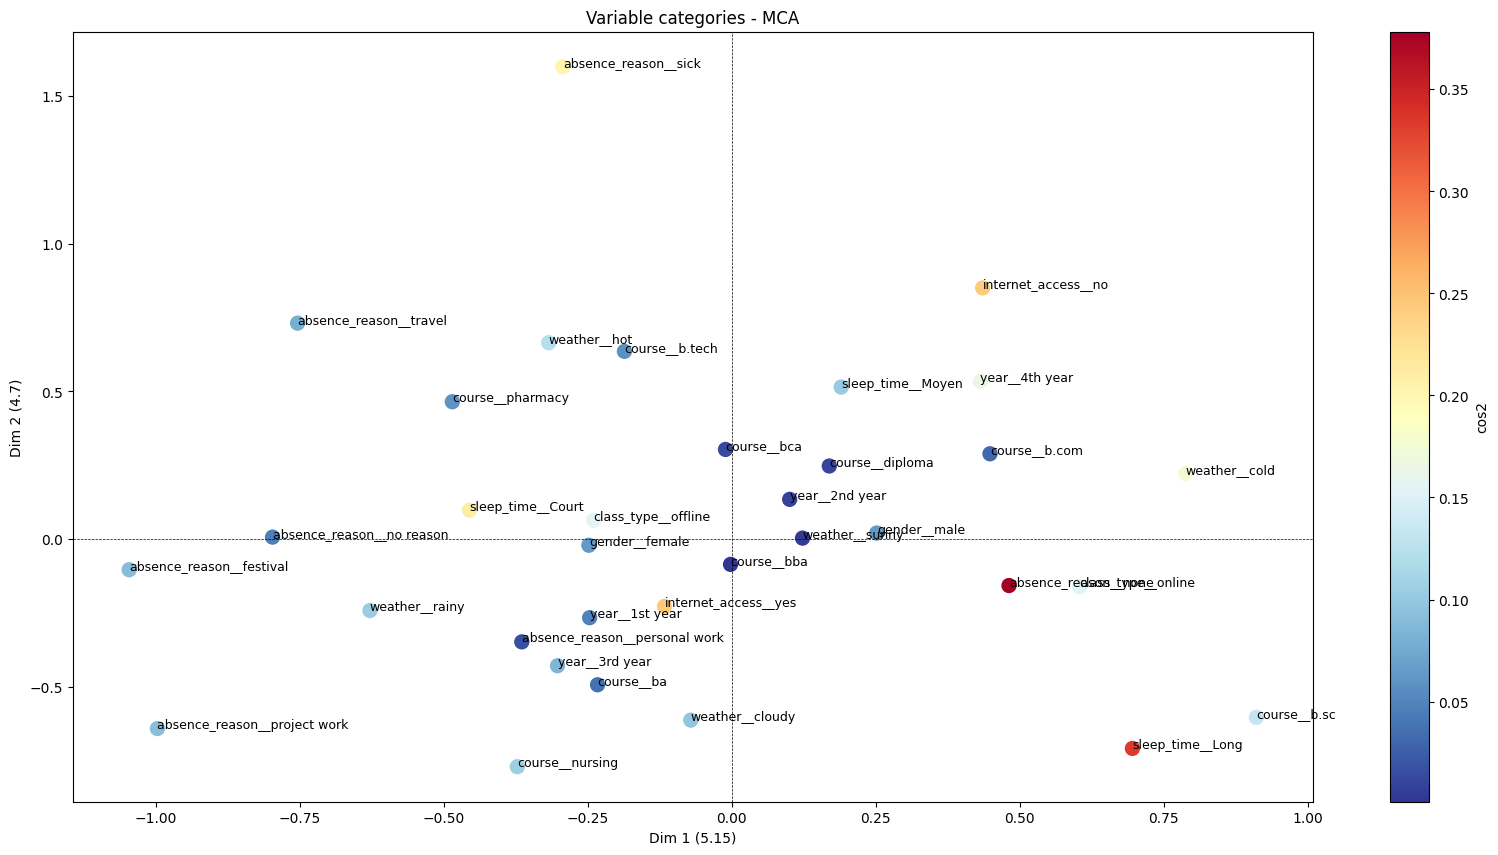

In [116]:
coords =mca.column_coordinates(df)
plt.figure(figsize=(20, 10))
scatter = plt.scatter(coords[0], coords[1], c=qualite_plan, cmap='RdYlBu_r', s=100)
plt.colorbar(scatter, label='cos2')

for i, txt in enumerate(coords.index):
    plt.annotate(txt, (coords.iloc[i, 0], coords.iloc[i, 1]), fontsize=9)

plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.title("Variable categories - MCA")
plt.xlabel(f"Dim 1 ({perc_var[0]})")
plt.ylabel(f"Dim 2 ({perc_var[1]})")
plt.show()